# Franklin LIP ca. 719 Ma paleomagnetic pole

## Geologic context

The Franklin Large Igneous Province is the ~719 Ma mafic dyke swarm with associated sills and volcanics emplaced across Arctic Canada and northwest Greenland, immediately preceding the Sturtian Snowball Earth in the late Tonian. Six zircon ²⁰⁶Pb/²³⁸U dates of 718.61 ± 0.30 to 719.86 ± 0.21 Ma (Pu et al., 2022) record its rapid emplacement. Its paleomagnetic pole is one of the best-determined Neoproterozoic keystones of the Laurentia APWP, carried by a magnetite-held, dual-polarity remanence and supported by a positive baked-contact test (Denyszyn et al., 2009).

## Which Franklin pole this notebook reproduces

Denyszyn et al. (2009), Table 3, report two grand-mean Franklin poles built from quality-filtered ("site-filtered") VGPs:

- **D+09can** — *Victoria Island–Baffin lavas and intrusions*, the site-filtered compilation of **previous Canadian studies** (Fahrig 1971; Robertson & Baragar 1972; Fahrig & Schwarz 1973; Park 1974; Palmer & Hayatsu 1975; Park 1981; Christie & Fahrig 1983; Palmer et al. 1983). 28 normal + 28 reverse = **56 VGPs**, giving **6.7°N, 162.1°E (A95 = 3.0°)**.
- **D+09cg** — *Canada **and** Greenland lavas and intrusions*, adding Denyszyn et al.'s own new Devon/Ellesmere and Greenland dykes (Greenland variably rotated to North America). 48 normal + 30 reverse = **78 VGPs**, giving **8.4°N, 163.8°E (A95 = 2.8°)**.

The **Nordic compilation entry** for the Franklin event grand mean (6.7°N, 162.1°E, A95 3.0°, B = 56) is the **D+09can** pole, so this notebook reproduces D+09can from its 56 constituent site VGPs. The broader Canada + Greenland mean (D+09cg) is computed below for comparison but is not the adopted value.

## Age constraints

- Six zircon ²⁰⁶Pb/²³⁸U dates of 718.61 ± 0.30 to 719.86 ± 0.21 Ma record the rapid emplacement of the Franklin LIP (Pu et al., 2022), superseding earlier baddeleyite dates (e.g. Denyszyn et al., 2009; Heaman et al., 1992).

## References

- Denyszyn, S. W., Halls, H. C., Davis, D. W., & Evans, D. A. D. (2009). Paleomagnetism and U-Pb geochronology of Franklin dykes in High Arctic Canada and Greenland: a revised age and paleomagnetic pole constraining block rotations in the Nares Strait region. *Canadian Journal of Earth Sciences*, 46(9), 689–705. https://doi.org/10.1139/E09-042
- Pu, J. P., Macdonald, F. A., Schmitz, M. D., et al. (2022). Emplacement of the Franklin large igneous province and initiation of the Sturtian Snowball Earth. *Science Advances*, 8, eadc9430. https://doi.org/10.1126/sciadv.adc9430
- Underlying Canadian site data: Fahrig et al. (1971); Fahrig & Schwarz (1973); Park (1974, 1981); Palmer & Hayatsu (1975); Christie & Fahrig (1983); Palmer et al. (1983). See `data/719_Franklin_LIP/site_refs.md`.

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

%config InlineBackend.figure_format='retina'
%matplotlib inline

## The compilation pole — Denyszyn et al. (2009) D+09can

`Denyszyn2009.csv` holds the site VGPs that Denyszyn et al. (2009) compiled for the Franklin grand mean, each tagged by source study and normal/reverse polarity (Greenland VGPs additionally carry a Laurentia-rotated position). The **D+09can** pole is the Fisher mean of the **56 VGPs from the previous Canadian studies** — i.e. all VGPs *except* Denyszyn et al.'s own new Devon/Ellesmere and Greenland dykes. The swarm is of mixed polarity (28 normal + 28 reverse), so polarity is unified before averaging.

In [2]:
franklin = pd.read_csv('../data/719_Franklin_LIP/Denyszyn2009.csv')
# D+09can = site-filtered previous Canadian studies (exclude Denyszyn et al. 2009's own dykes)
d09can = franklin[~franklin['reference'].str.startswith('Denyszyn et al. 2009')].copy()
d09can = d09can.drop(columns=['vgp_lat', 'vgp_lon']).rename(
    columns={'vgp_lat_rotated': 'vgp_lat', 'vgp_lon_rotated': 'vgp_lon'})
print(f'D+09can: {len(d09can)} site VGPs; polarity {d09can["polarity"].value_counts().to_dict()}')
print('by source study:')
print(d09can['reference'].value_counts().to_string())

vgp_block, pole_mean = pt.compute_mean_pole(d09can, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print('\nNordic compilation / paper D+09can target: 6.7 N / 162.1 E, A95 3.0, N = 56')

D+09can: 56 site VGPs; polarity {'r': 28, 'n': 28}
by source study:
reference
Fahrig et al. 1971                                          19
Palmer et al. 1983 Natkusiak middle+upper polarity zones    12
Christie+Fahrig 1983 NW Baffin (Borden basin)                9
Fahrig+Schwarz 1973 Baffin dikes (new)                       8
Palmer+Hayatsu 1975 Victoria Island                          3
Park 1981 Brock inlier                                       3
Park 1974 misc dikes                                         2
Plon: 162.1  Plat: 6.7
Number of directions in mean (n): 56
Angular radius of 95% confidence (A_95): 3.0
Precision parameter (k) estimate: 42.4

Nordic compilation / paper D+09can target: 6.7 N / 162.1 E, A95 3.0, N = 56


## Reversal test (site VGPs)

Site-level directions are not tabulated in the compilation, so the reversal test
uses the site VGPs as the directional data. The reversed-polarity sites are listed
already flipped into the pole hemisphere; they are restored to their antipodes to
recover the raw bipolar set before being unified, and the McFadden & McElhinny
(1990) and bootstrap reversal tests are then applied (splitting by principal
eigenvector).

56 directions (polarity 1: 28, polarity 2: 28)

McFadden & McElhinny (1990) reversal test
------------------------------------------
Results of Watson V test: 

Watson's V:           3.7
Critical value of V:  6.3
"Pass": Since V is less than Vcrit, the null hypothesis
that the two populations are drawn from distributions
that share a common mean direction can not be rejected.

M&M1990 classification:

Angle between data set means: 4.5
Critical angle for M&M1990:   5.9
The McFadden and McElhinny (1990) classification for
this test is: 'B'


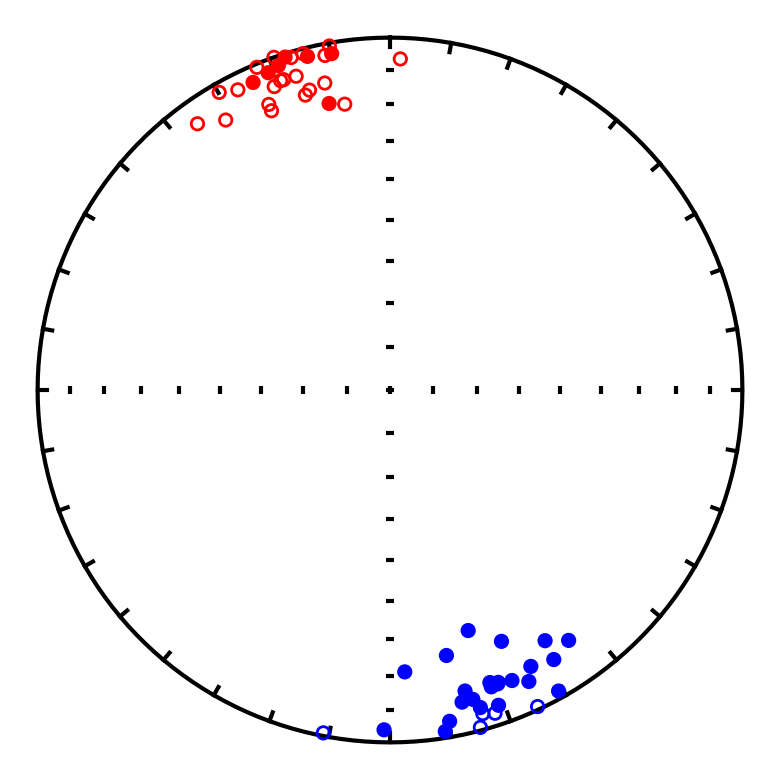


Bootstrap reversal test
------------------------------------------


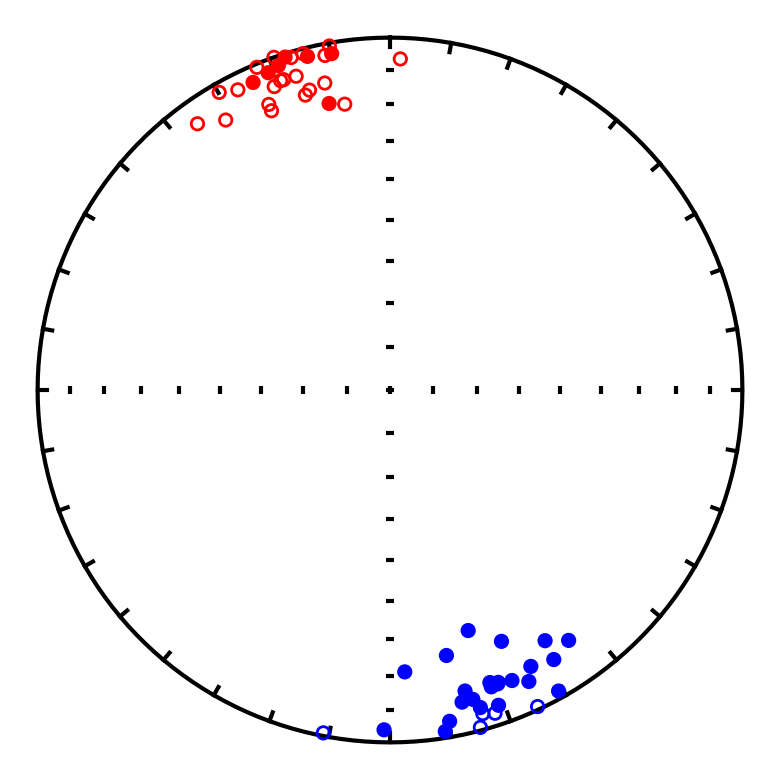

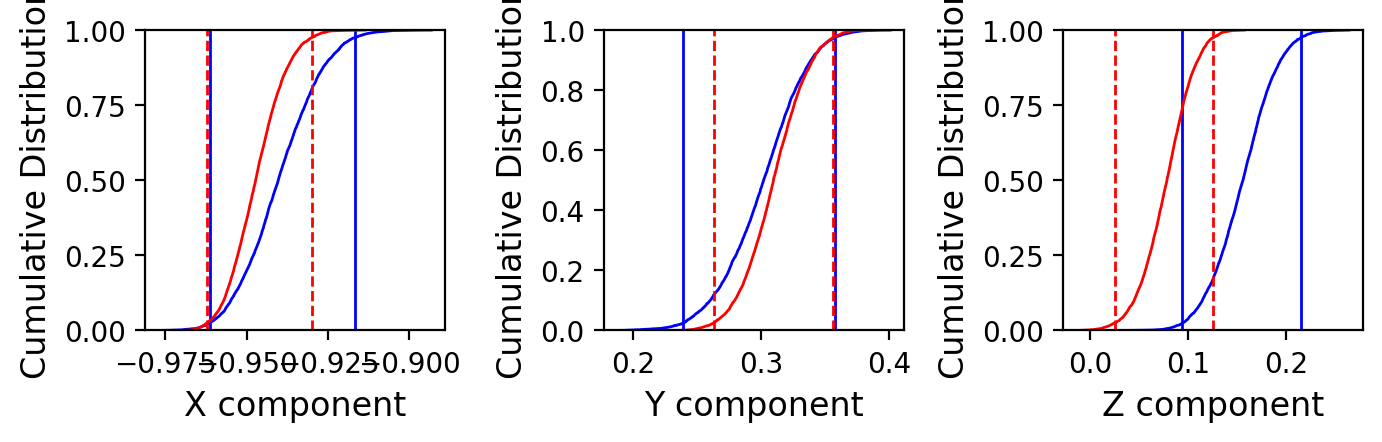

Pass


In [3]:
# the VGPs serve as the directional data; restore reversed sites to their antipode
# to recover the raw bipolar set (the compilation lists them flipped to the pole)
rev_test = d09can.assign(dir_dec=d09can['vgp_lon'].astype(float),
                         dir_inc=d09can['vgp_lat'].astype(float))
rev = rev_test['polarity'] == 'r'
rev_test.loc[rev, 'dir_dec'] = (rev_test.loc[rev, 'vgp_lon'].astype(float) + 180) % 360
rev_test.loc[rev, 'dir_inc'] = -rev_test.loc[rev, 'vgp_lat'].astype(float)
_ = pt.reversal_test(rev_test, plot=True, random_seed=1)

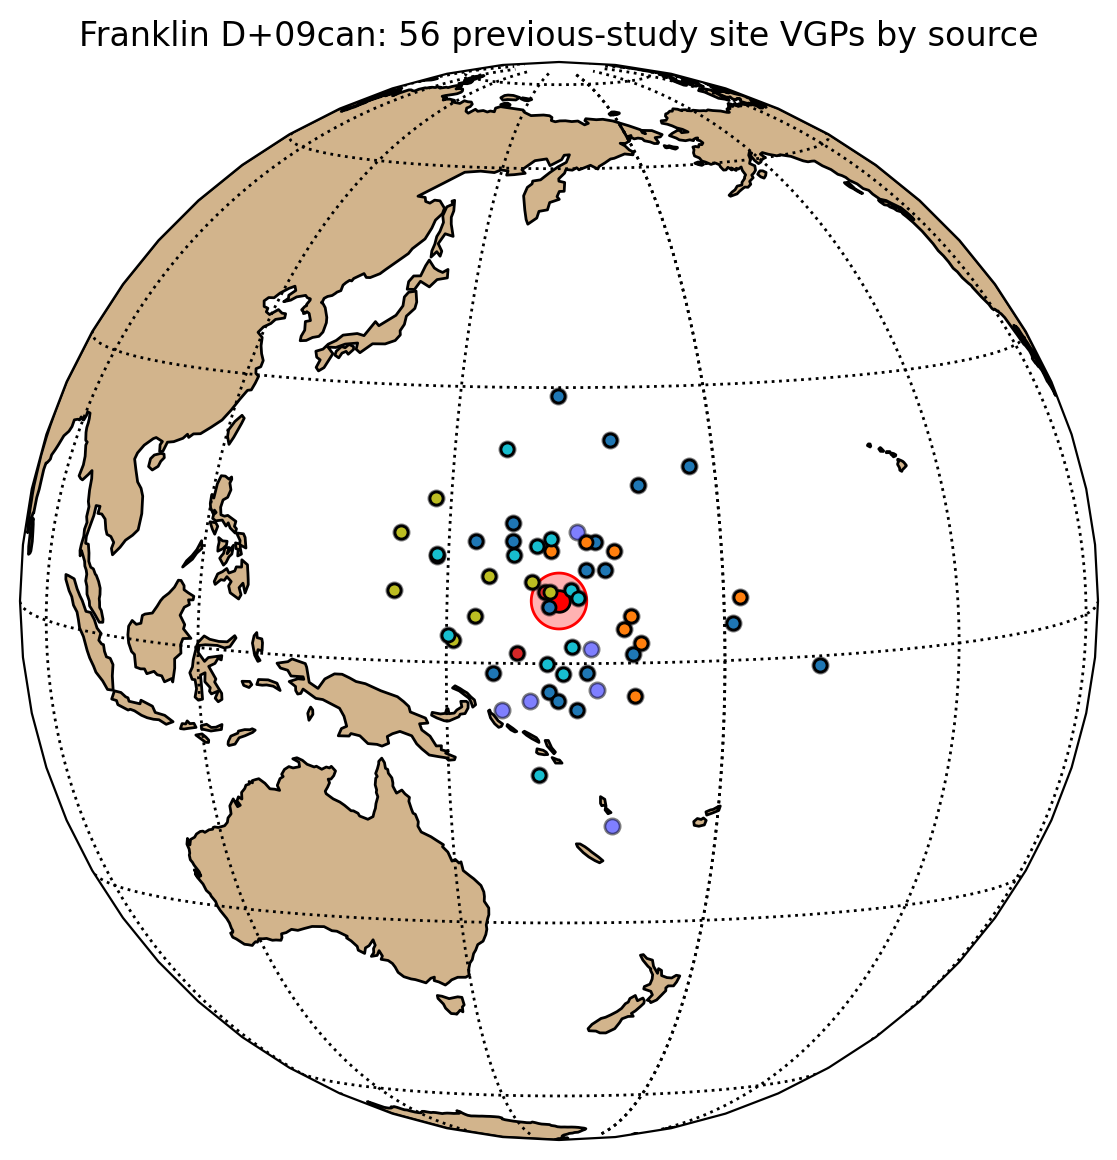

In [4]:
# plot the 56 D+09can site VGPs coloured by source study, with the mean pole
ax = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                           central_latitude=pole_mean['inc'], figsize=(7, 7))
refs = list(d09can['reference'].unique())
colors = cm.tab10(np.linspace(0, 1, len(refs)))
for ref, c in zip(refs, colors):
    sub = d09can[d09can['reference'] == ref]
    blk = pmag.flip(ipmag.make_di_block(sub['vgp_lon'].tolist(), sub['vgp_lat'].tolist()), combine=True)
    for lon, lat in blk:
        ipmag.plot_vgp(ax, lon, lat, color=c, markersize=22)
plt.title('Franklin D+09can: 56 previous-study site VGPs by source')
plt.show()

## For comparison: the Canada + Greenland grand mean (D+09cg)

Adding Denyszyn et al.'s own 12 Devon/Ellesmere and 10 Greenland dykes (Greenland rotated to North America) gives the broader **D+09cg** mean of all 78 VGPs. Its position (≈8°N, 162°E) differs from D+09can mainly because of the added Greenland/Ellesmere sites and their restoration; the Nordic compilation adopts **D+09can**, not this value.

In [5]:
all78 = franklin.dropna(subset=['vgp_lat_rotated', 'vgp_lon_rotated']).drop(
    columns=['vgp_lat', 'vgp_lon']).rename(
    columns={'vgp_lat_rotated': 'vgp_lat', 'vgp_lon_rotated': 'vgp_lon'})
_, pole_cg = pt.compute_mean_pole(all78, unify_polarity=True)
print(f'D+09cg (all {int(pole_cg["n"])} VGPs): {pole_cg["inc"]:.1f} N / {pole_cg["dec"]:.1f} E, '
      f'A95 {pole_cg["alpha95"]:.1f}')
print('paper D+09cg: 8.4 N / 163.8 E, A95 2.8, N = 78 (Greenland variably rotated)')

D+09cg (all 78 VGPs): 9.0 N / 161.7 E, A95 2.9
paper D+09cg: 8.4 N / 163.8 E, A95 2.8, N = 78 (Greenland variably rotated)


## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the D+09can site VGPs are drawn
from a Fisher distribution, and the shape-elongation/inclination (SVEI) test
compares the VGP-scatter elongation against the TK03.GAD paleosecular-variation
model expectation at the sampling paleolatitude.

{'Mode': 'Mode 1',
 'Dec': np.float64(161.9948333193565),
 'Inc': np.float64(6.681863821958639),
 'N': 56,
 'Mu': np.float64(0.9340857352200006),
 'Mu_critical': 1.207,
 'Me': np.float64(0.6854441548519601),
 'Me_critical': 1.094,
 'Test_result': 'Consistent with Fisher distribution'}

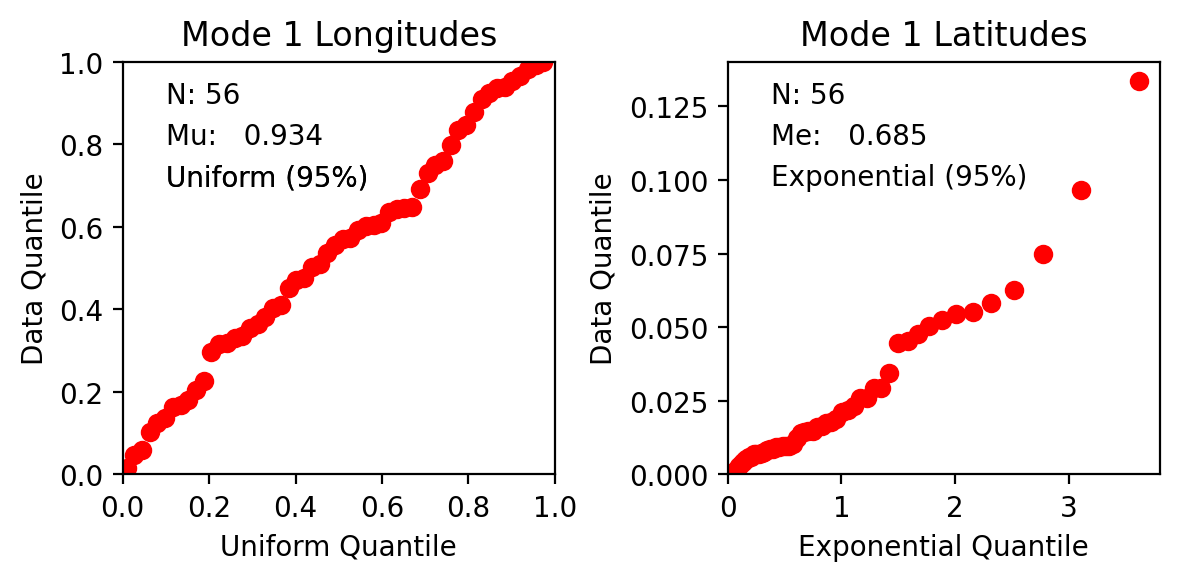

In [6]:
fishqq_result = pt.fishqq_vgps(d09can, unify_polarity=False)
fishqq_result

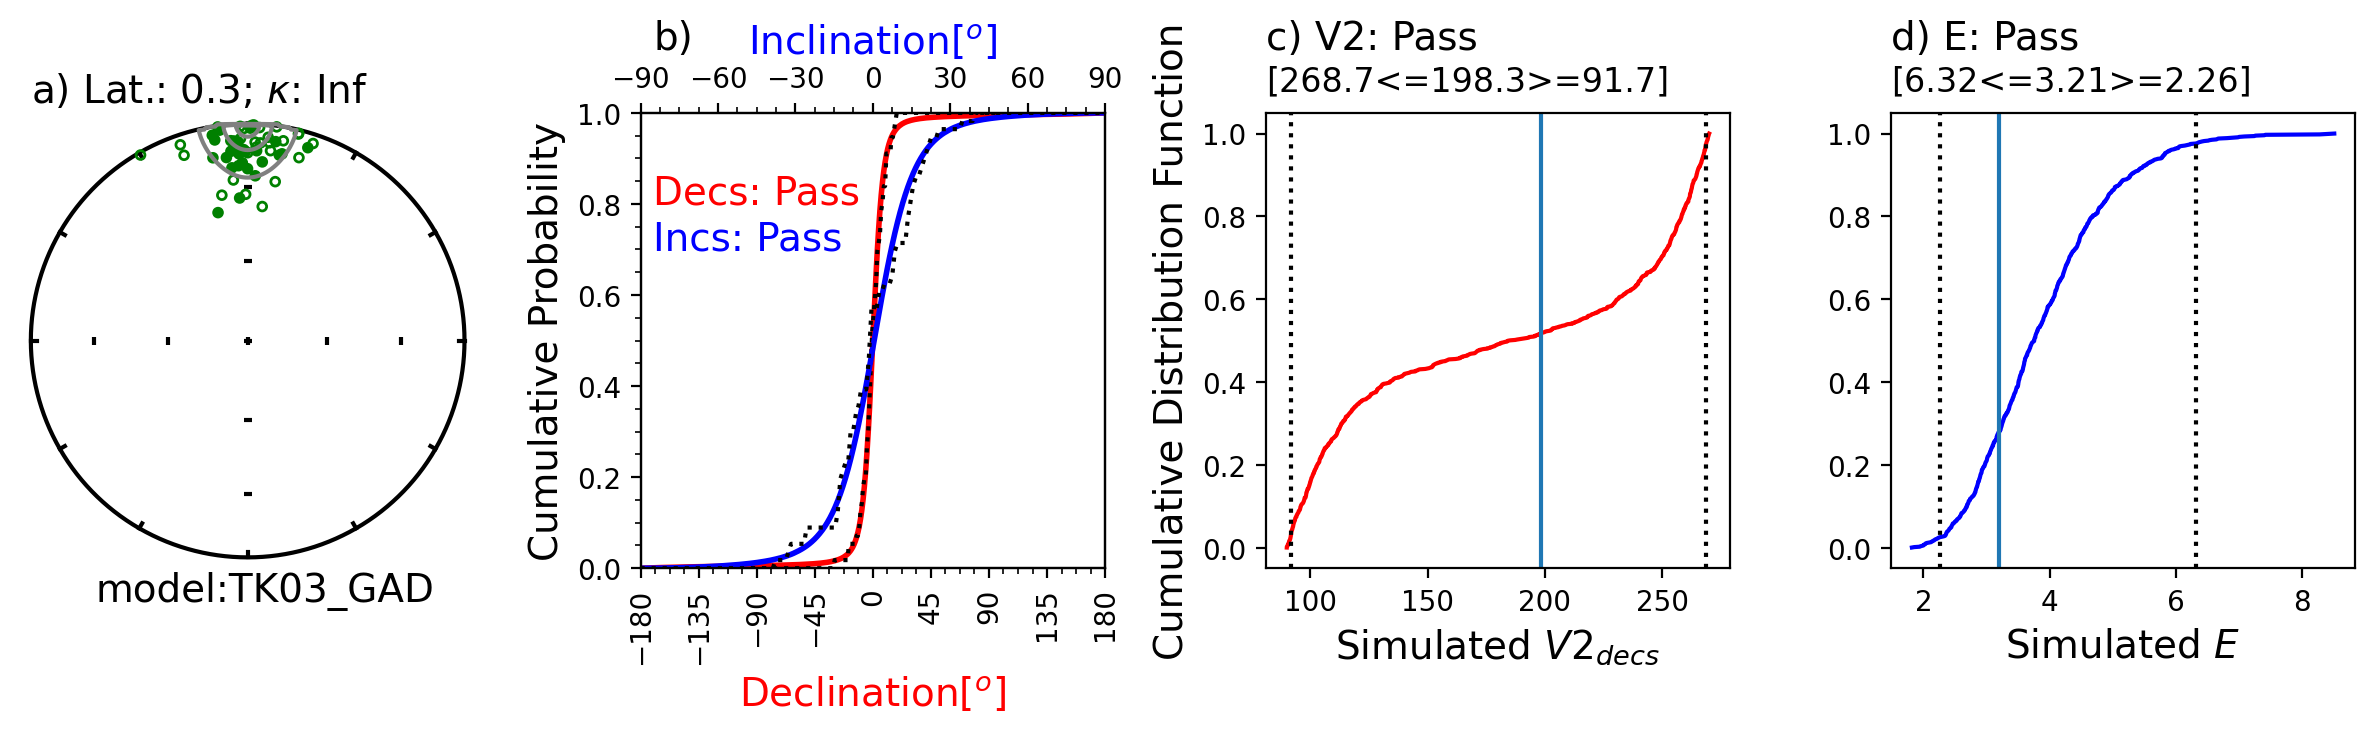

paleolatitude = 0.3 deg; elongation E = 3.21 (consistent with TK03.GAD)


In [7]:
study_lat, study_lon = 73.0, 275.4   # representative High Arctic Canada locality
try:
    svei_result = pt.svei_test_vgps(d09can, study_lon, study_lat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(d09can, study_lon, study_lat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## Pole in the context of the Laurentia APWP

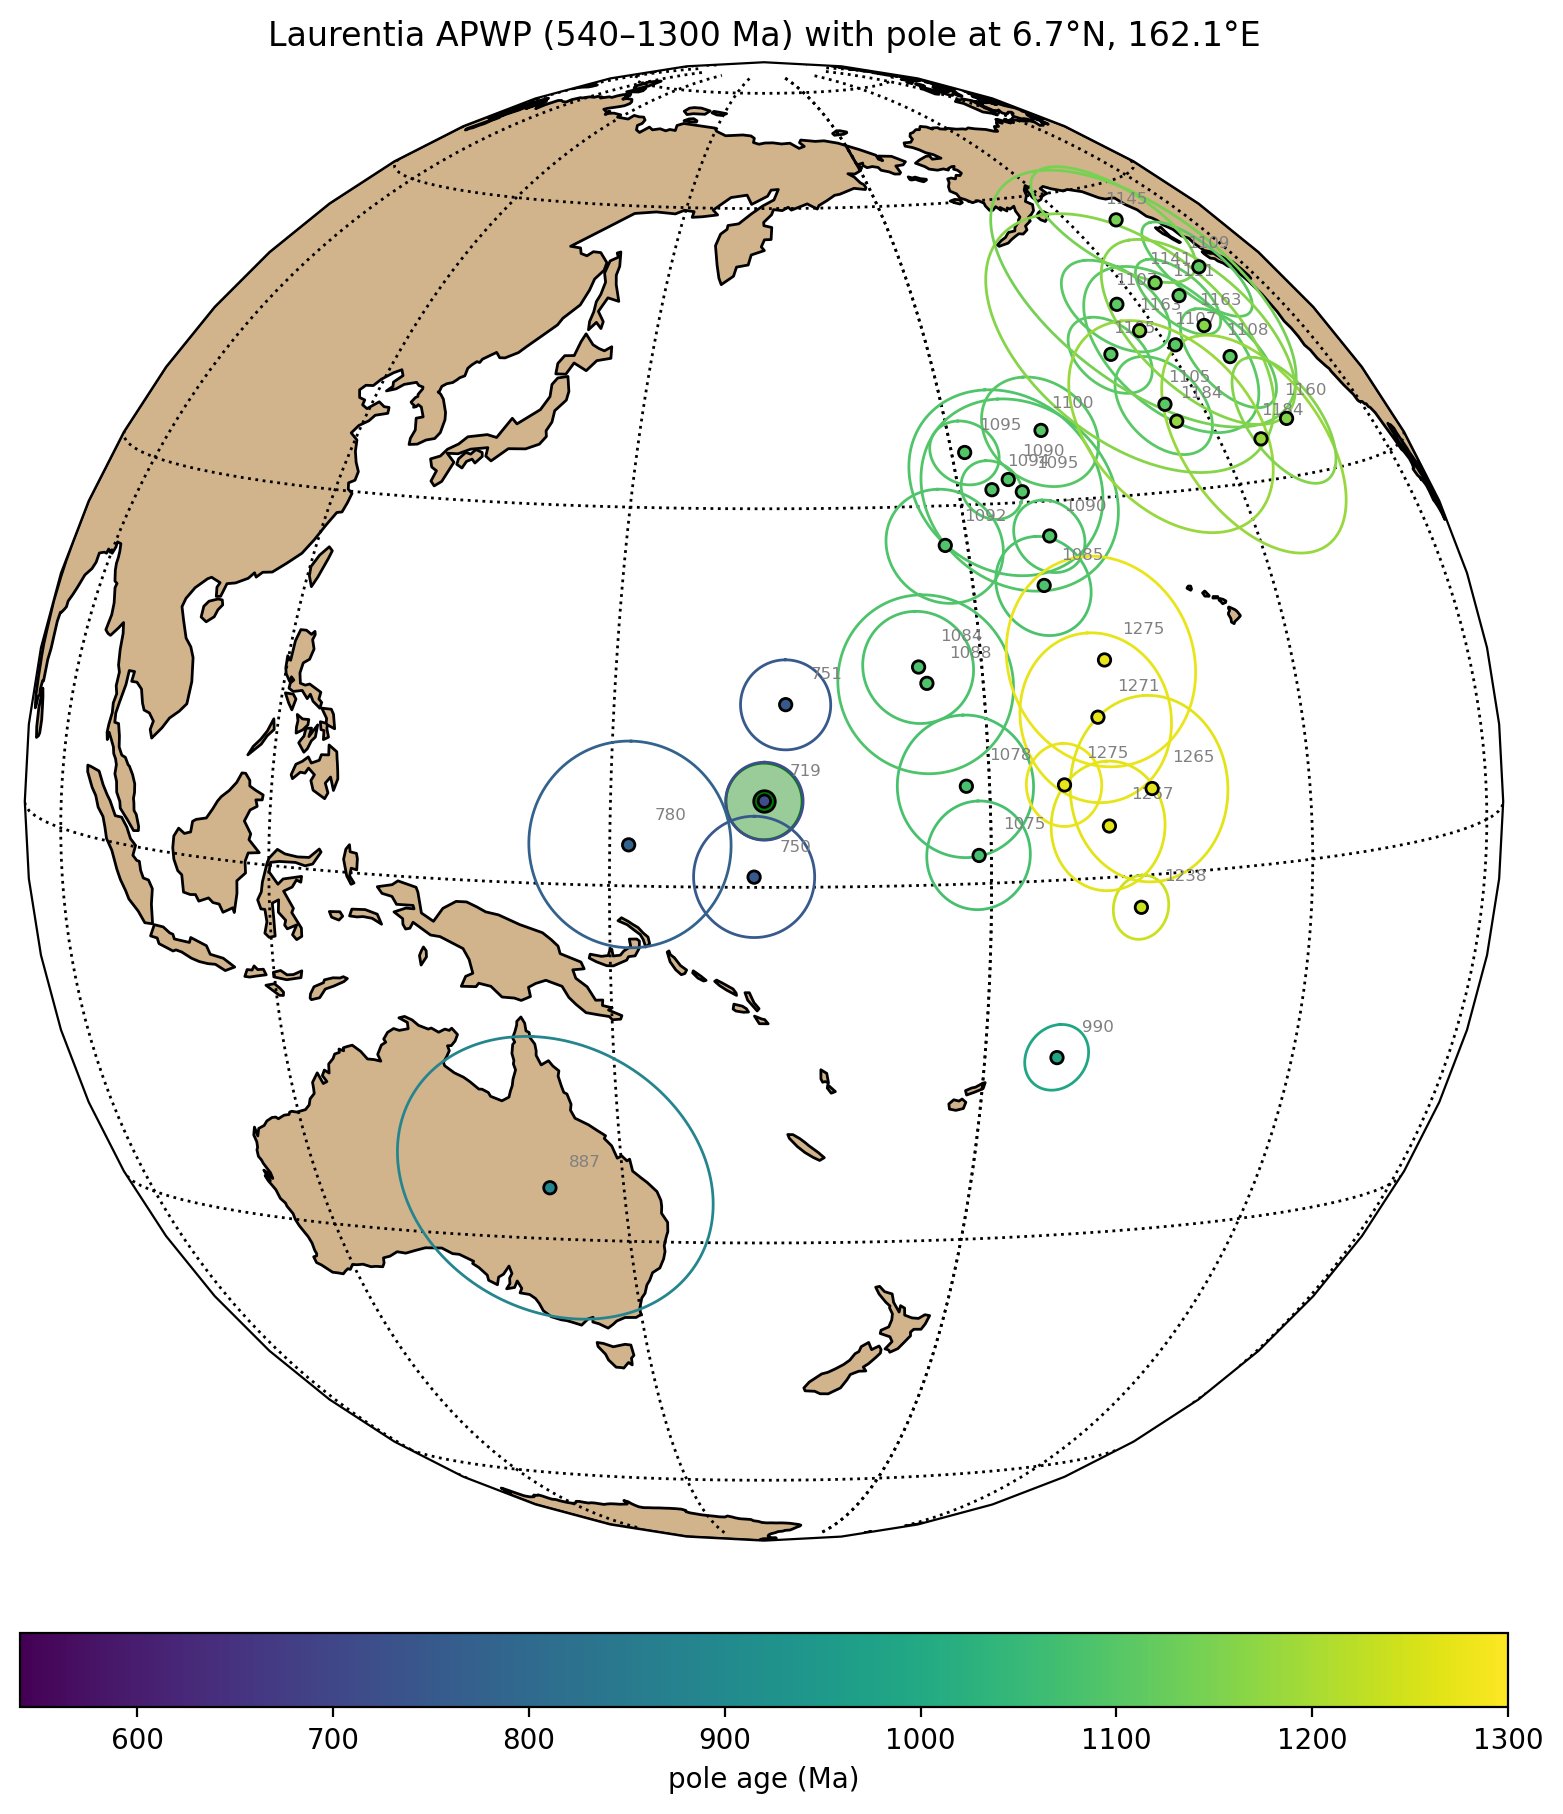

In [8]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=540, age_max=1300,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

The Franklin pole resembles some Middle–Late Cambrian Laurentia poles, but Denyszyn et al.'s (2009) positive baked-contact test demonstrates the magnetization is the ~719 Ma primary remanence, so that resemblance is coincidental and R7 is satisfied.

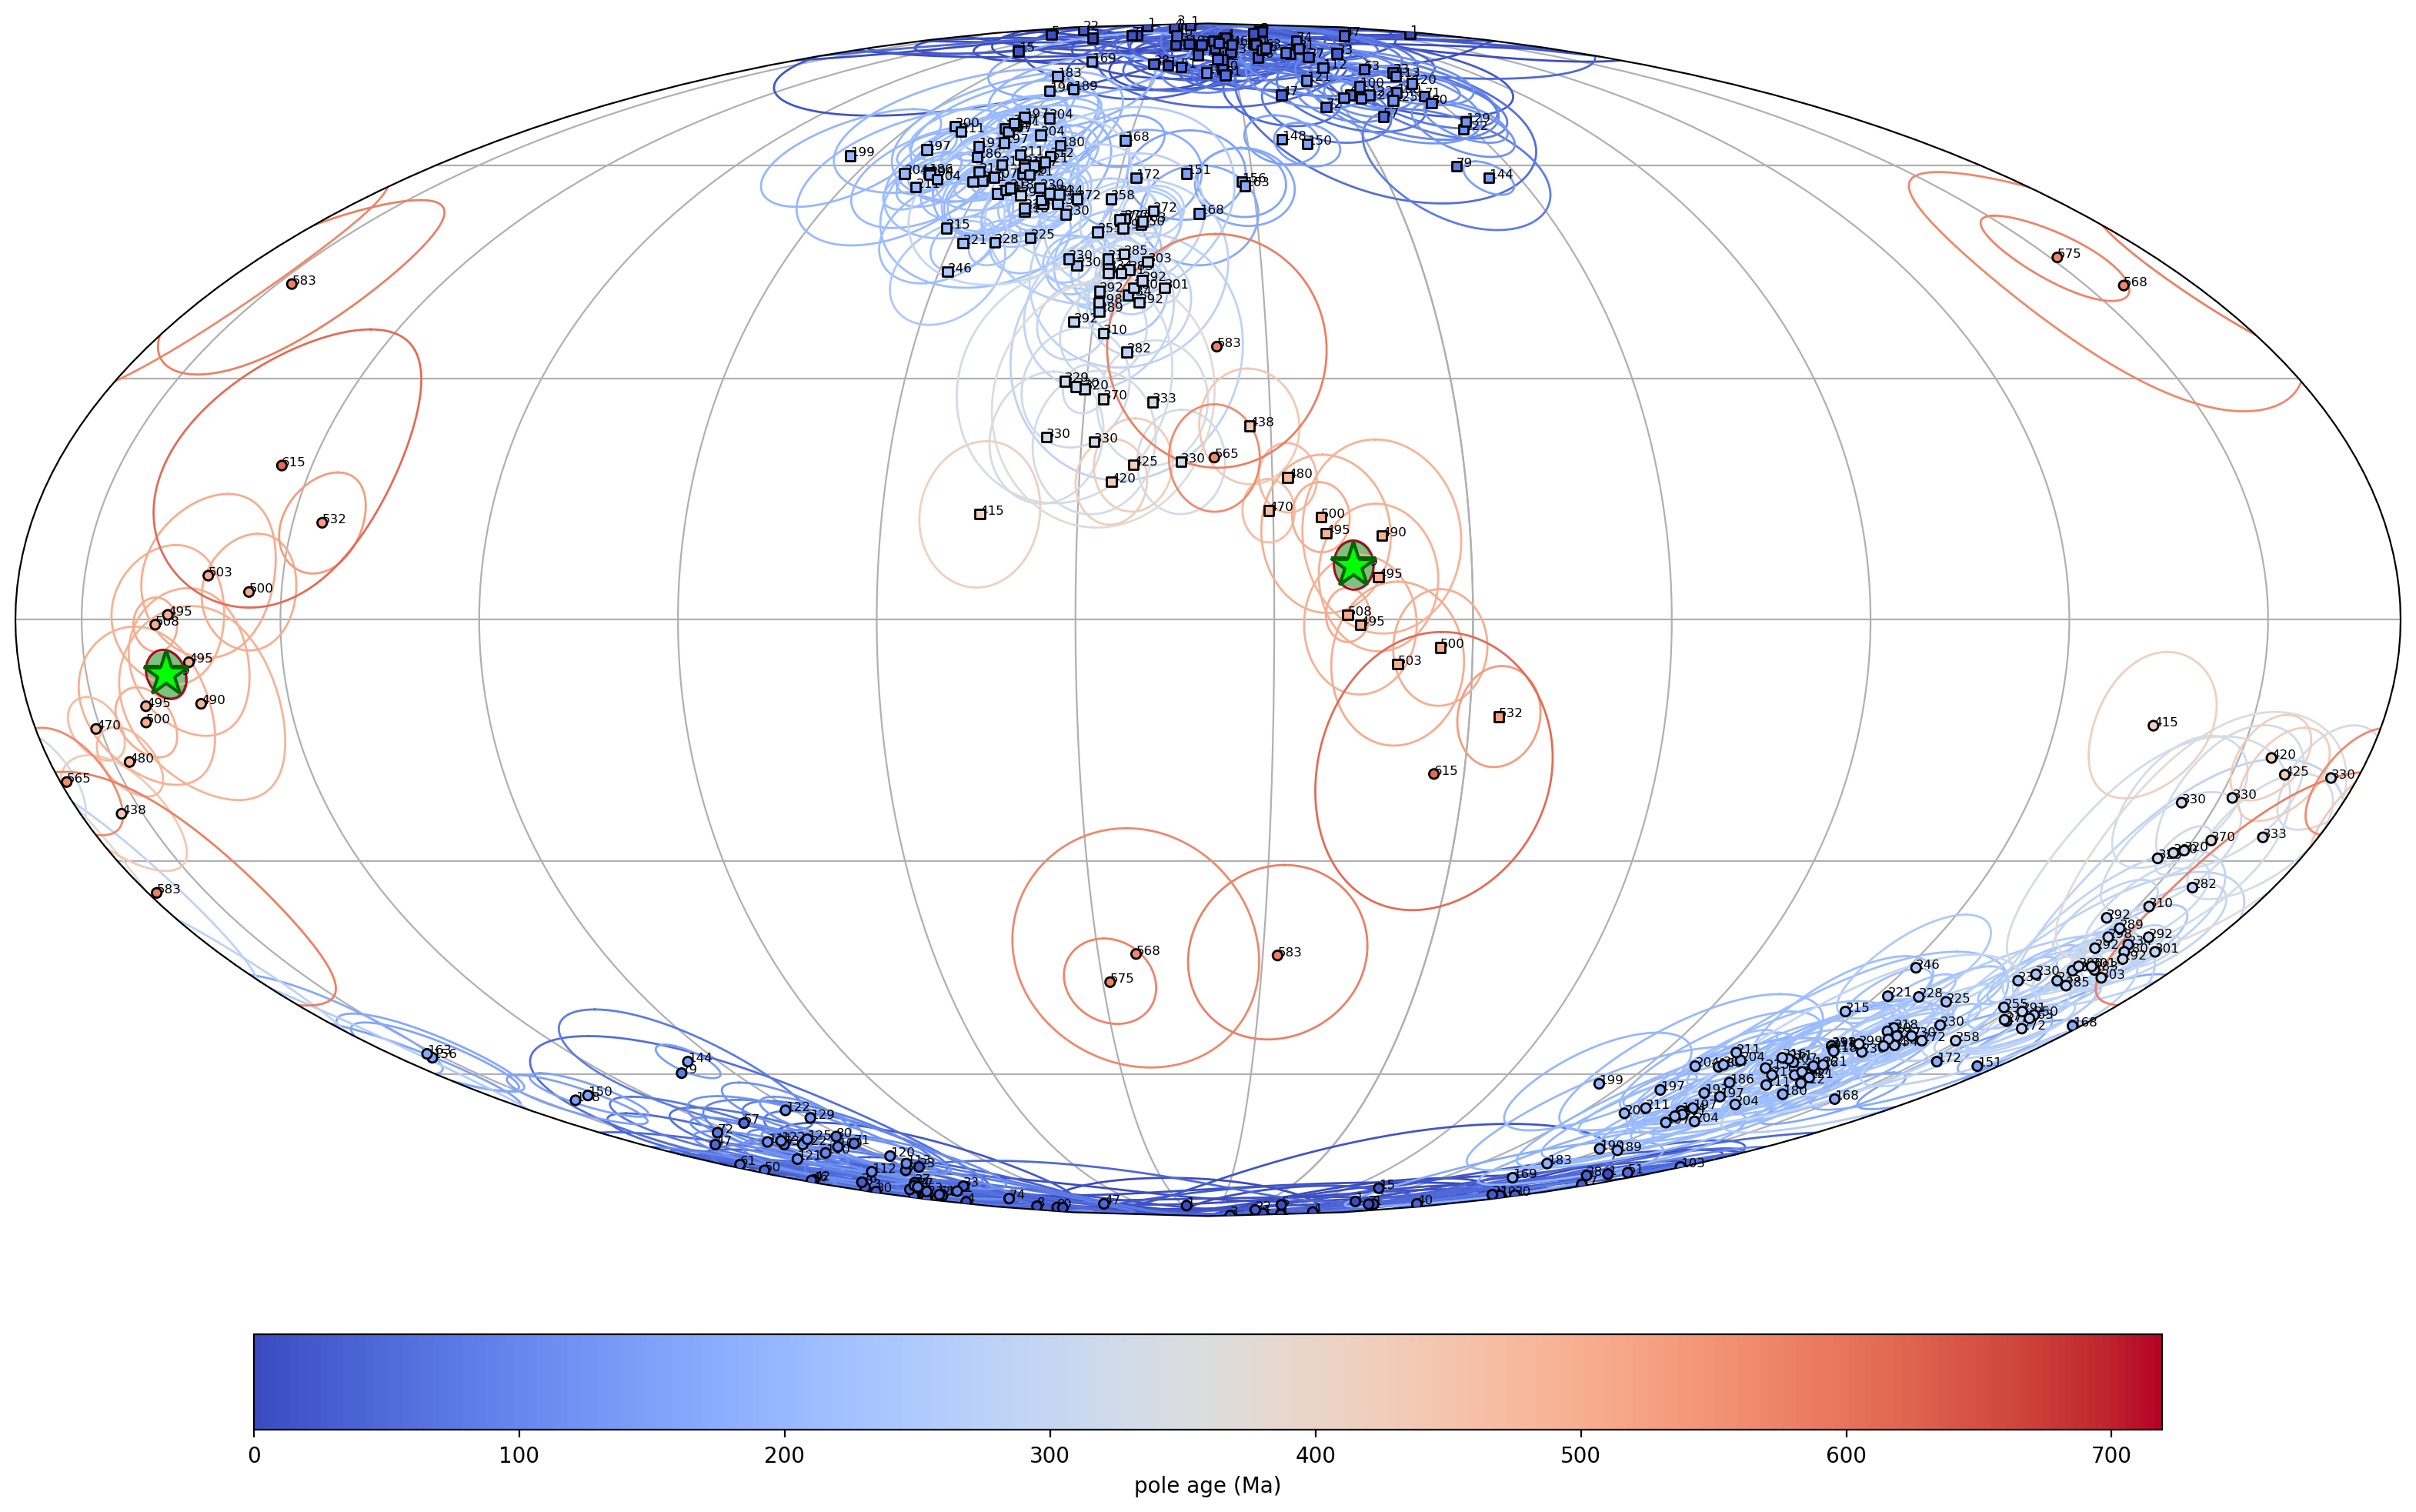

In [9]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Franklin event grand mean', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=719)
plt.show()

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | Six zircon ²⁰⁶Pb/²³⁸U dates 718.61 ± 0.30 to 719.86 ± 0.21 Ma (Pu et al., 2022). |
| 2 | Techniques and statistical analysis | **1** | A site-filtered grand mean of 56 VGPs from seven studies, thoroughly averaging paleosecular variation (k = 42, A95 = 3.0°, B = 56 ≥ 8). |
| 3 | Magnetic mineralogy characterized | **1** | Low-Ti magnetite remanence characterized (Denyszyn et al., 2009 and source studies). |
| 4 | Field tests constrain age of magnetization | **C** | The Franklin dykes have one well-supported baked-contact test, at GR in Denyszyn et al. (2009), plus two earlier claimed/apparent tests from Christie and Fahrig (1983) that were later regarded as equivocal.|
| 5 | Structural control / tectonic coherence | **1** | Autochthonous Laurentia; the Canadian VGPs require no plate restoration. |
| 6 | Presence of reversals | **1** | The swarm is of mixed polarity (28 normal, 28 reverse) with a positive reversal test on the site VGPs (McFadden & McElhinny 1990 class B; modes ~4.5° apart). |
| 7 | No resemblance to younger poles | **1** | Resemblance to Middle–Late Cambrian poles is shown to be coincidental by the positive baked-contact test. |
| | Total | **7/7** | Grade A |

## Nordic workshop summary

The Franklin event grand mean adopted in the compilation is **D+09can** — Denyszyn et al.'s (2009) site-filtered mean of the previous Canadian Franklin studies (Victoria Island–Baffin), recreated here from its 56 site VGPs as **6.7°N, 162.1°E (A95 = 3.0°, B = 56)**, reproducing the compilation value exactly. A positive baked-contact test, mixed polarity, and the 719 Ma zircon ages make it a Grade A, R = 7 keystone pole.

### Franklin event grand mean (D+09can) pole

| | This study (site VGPs) | Denyszyn et al. (2009) | Previous Nordic compilation |
|---|---|---|---|
| Component | Primary ChRM (magnetite), mixed polarity | D+09can grand mean | Combined Result |
| N (sites) | 56 | 56 (28 N + 28 R) | 56 |
| N (specimens) | — | — | — |
| Dec (°) | 114.3 | — | — |
| Inc (°) | 0.4 | — | — |
| k (direction) | 19.6 | — | — |
| α95 (direction, °) | 4.4 | — | — |
| Pole lat (°N) | 6.7 | 6.7 | 6.7 |
| Pole lon (°E) | 162.1 | 162.1 | 162.1 |
| A95 | 3.0 | 3.0 | 3.0 |
| pole (°) | — | — | — |
| dp / dm (°) | — / — | — / — | 3.0 / 3.0 |


In [10]:
# the 56 D+09can VGPs serve as the "sites" (one VGP per site); B and N reflect them
grand_sites = d09can.copy()
grand_sites['dir_tilt_correction'] = 0
grand_sites['dir_n_samples'] = 1
study_lat, study_lon = 73.0, 275.4
_, dir_mean = pt.compute_mean_direction_from_vgps(grand_sites, study_lon, study_lat, unify_polarity=True)

franklin_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Franklin event grand mean',
    sites=grand_sites,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Primary characteristic remanent magnetization (magnetite); mixed polarity; Franklin D+09can grand mean of 56 previous-study Canada site VGPs',
    tests='C+ (positive baked-contact test; Denyszyn et al., 2009)',
    gpmdb_number='',
    magic_id='',
    percent_reversed=50,
    demag_code=4,
    R1=1, R2=1, R3=1, R4='C', R5=1, R6=1, R7=1, Grade='A',
    nominal_age=719, lomagage=718, himagage=720,
    REF_method='Six zircon 206Pb/238U dates 718.61 +/- 0.30 to 719.86 +/- 0.21 Ma record rapid emplacement of the Franklin LIP (Pu et al., 2022), superseding earlier baddeleyite dates.',
    POLE_AUTHORS='Denyszyn, S. W., Halls, H. C., Davis, D. W., & Evans, D. A. D.',
    YEAR=2009,
    JOURNAL='Canadian Journal of Earth Sciences',
    VOLUME='46',
    VPAGES='689-705',
    TITLE='Paleomagnetism and U-Pb geochronology of Franklin dykes in High Arctic Canada and Greenland',
    COMMENT='Reproduces the Nordic compilation Franklin value = Denyszyn et al. (2009) Table 3 "D+09can" pole: the site-filtered grand mean of previous Canadian Franklin studies (Victoria Island-Baffin), 56 site VGPs (28 normal + 28 reverse; Fahrig 1971, Fahrig+Schwarz 1973, Park 1974/1981, Palmer+Hayatsu 1975, Christie+Fahrig 1983, Palmer et al. 1983) from data/719_Franklin_LIP/Denyszyn2009.csv. Recreated 6.7N/162.1E, A95 3.0, N=56. The broader Canada+Greenland mean (D+09cg, 8.4N/163.8E, N=78) is not the adopted value. Mixed polarity (R6=1); positive baked-contact test (R4=C); zircon 206Pb/238U 718.6-719.9 Ma (Pu et al. 2022, R1=1). R=7, Grade A.'
)
pt.save_nordic_summary(franklin_summary, '719_Franklin_LIP')
franklin_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Franklin event grand mean,,Primary characteristic remanent magnetization ...,C+ (positive baked-contact test; Denyszyn et a...,0,73.0,275.4,56,56,...,720,Six zircon 206Pb/238U dates 718.61 +/- 0.30 to...,Franklin event grand mean,"Denyszyn, S. W., Halls, H. C., Davis, D. W., &...",2009,Canadian Journal of Earth Sciences,46,689-705,Paleomagnetism and U-Pb geochronology of Frank...,Reproduces the Nordic compilation Franklin val...
